<a href="https://colab.research.google.com/github/HeliosRider/deep-learning-challenge/blob/main/AlphabetSoupCharity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preprocessing

In [1]:
# Import our dependencies
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt

# Import pandas and read the charity_data.csv from the provided cloud URL.
import pandas as pd
application_df = pd.read_csv("https://static.bc-edx.com/data/dl-1-2/m21/lms/starter/charity_data.csv")
application_df.tail()

,EIN,NAME,APPLICATION_TYPE,AFFILIATION,CLASSIFICATION,USE_CASE,ORGANIZATION,STATUS,INCOME_AMT,SPECIAL_CONSIDERATIONS,ASK_AMT,IS_SUCCESSFUL
34294,996009318,THE LIONS CLUB OF HONOLULU KAMEHAMEHA,T4,Independent,C1000,ProductDev,Association,1,0,N,5000,0
34295,996010315,INTERNATIONAL ASSOCIATION OF LIONS CLUBS,T4,CompanySponsored,C3000,ProductDev,Association,1,0,N,5000,0
34296,996012607,PTA HAWAII CONGRESS,T3,CompanySponsored,C2000,Preservation,Association,1,0,N,5000,0
34297,996015768,AMERICAN FEDERATION OF GOVERNMENT EMPLOYEES LO...,T5,Independent,C3000,ProductDev,Association,1,0,N,5000,1
34298,996086871,WATERHOUSE CHARITABLE TR,T3,Independent,C1000,Preservation,Co-operative,1,1M-5M,N,36500179,0


In [2]:
# Verify number of samples and features in current DatatFrame.
application_df.shape


(34299, 12)

In [3]:
# Drop the non-beneficial ID columns, 'EIN' and 'NAME'.

new_application_df = application_df.drop(columns=['EIN','NAME'])
new_application_df.head()

,APPLICATION_TYPE,AFFILIATION,CLASSIFICATION,USE_CASE,ORGANIZATION,STATUS,INCOME_AMT,SPECIAL_CONSIDERATIONS,ASK_AMT,IS_SUCCESSFUL
0,T10,Independent,C1000,ProductDev,Association,1,0,N,5000,1
1,T3,Independent,C2000,Preservation,Co-operative,1,1-9999,N,108590,1
2,T5,CompanySponsored,C3000,ProductDev,Association,1,0,N,5000,0
3,T3,CompanySponsored,C2000,Preservation,Trust,1,10000-24999,N,6692,1
4,T3,Independent,C1000,Heathcare,Trust,1,100000-499999,N,142590,1


In [4]:
# Verify number of samples and features updated from dropping 'EIN' and 'NAME'.
new_application_df.shape

(34299, 10)

In [5]:
# Determine the number of unique values in each column.
new_application_df.nunique()

,0
APPLICATION_TYPE,17
AFFILIATION,6
CLASSIFICATION,71
USE_CASE,5
ORGANIZATION,4
STATUS,2
INCOME_AMT,9
SPECIAL_CONSIDERATIONS,2
ASK_AMT,8747
IS_SUCCESSFUL,2


In [6]:
# Look at APPLICATION_TYPE value counts to identify and replace with "Other"
apptype_count = new_application_df['APPLICATION_TYPE'].value_counts()
apptype_count

,count
APPLICATION_TYPE,
T3,27037
T4,1542
T6,1216
T5,1173
T19,1065
T8,737
T7,725
T10,528
T9,156


In [7]:
# Choose a cutoff value and create a list of application types to be replaced
# use the variable name `application_types_to_replace`
application_types_to_replace = []

for i, v in apptype_count.items():
    if v < 500:
        application_types_to_replace.append(i)

# Replace in dataframe
for app in application_types_to_replace:
    new_application_df['APPLICATION_TYPE'] = new_application_df['APPLICATION_TYPE'].replace(app,"Other")

# Check to make sure replacement was successful
new_application_df['APPLICATION_TYPE'].value_counts()

,count
APPLICATION_TYPE,
T3,27037
T4,1542
T6,1216
T5,1173
T19,1065
T8,737
T7,725
T10,528
Other,276


In [8]:
# Look at CLASSIFICATION value counts to identify and replace with "Other"
class_count = new_application_df['CLASSIFICATION'].value_counts()
class_count

,count
CLASSIFICATION,
C1000,17326
C2000,6074
C1200,4837
C3000,1918
C2100,1883
...,...
C4120,1
C8210,1
C2561,1


In [9]:
# You may find it helpful to look at CLASSIFICATION value counts >1
classification_to_replace = []

for i, v in class_count.items():
    if v > 1:
        print(i, v)

C1000 17326
C2000 6074
C1200 4837
C3000 1918
C2100 1883
C7000 777
C1700 287
C4000 194
C5000 116
C1270 114
C2700 104
C2800 95
C7100 75
C1300 58
C1280 50
C1230 36
C1400 34
C7200 32
C2300 32
C1240 30
C8000 20
C7120 18
C1500 16
C1800 15
C6000 15
C1250 14
C8200 11
C1238 10
C1278 10
C1235 9
C1237 9
C7210 7
C2400 6
C1720 6
C4100 6
C1257 5
C1600 5
C1260 3
C2710 3
C0 3
C3200 2
C1234 2
C1246 2
C1267 2
C1256 2


In [10]:
# Choose a cutoff value and create a list of classifications to be replaced
# use the variable name `classifications_to_replace`
classifications_to_replace = []

for i, v in class_count.items():
    if v < 1000:
        classifications_to_replace.append(i)

# Replace in dataframe
for cls in classifications_to_replace:
   new_application_df['CLASSIFICATION'] = new_application_df['CLASSIFICATION'].replace(cls,"Other")

# Check to make sure replacement was successful
new_application_df['CLASSIFICATION'].value_counts()

,count
CLASSIFICATION,
C1000,17326
C2000,6074
C1200,4837
Other,2261
C3000,1918
C2100,1883


In [11]:
# Convert categorical data to numeric with `pd.get_dummies`
new_application_df = pd.get_dummies(new_application_df)
new_application_df.tail()

,STATUS,ASK_AMT,IS_SUCCESSFUL,APPLICATION_TYPE_Other,APPLICATION_TYPE_T10,APPLICATION_TYPE_T19,APPLICATION_TYPE_T3,APPLICATION_TYPE_T4,APPLICATION_TYPE_T5,APPLICATION_TYPE_T6,...,INCOME_AMT_1-9999,INCOME_AMT_10000-24999,INCOME_AMT_100000-499999,INCOME_AMT_10M-50M,INCOME_AMT_1M-5M,INCOME_AMT_25000-99999,INCOME_AMT_50M+,INCOME_AMT_5M-10M,SPECIAL_CONSIDERATIONS_N,SPECIAL_CONSIDERATIONS_Y
34294,1,5000,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
34295,1,5000,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
34296,1,5000,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
34297,1,5000,1,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
34298,1,36500179,0,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [12]:
# Split our preprocessed data into our features and target arrays
y = new_application_df['IS_SUCCESSFUL'].values
X = new_application_df.drop(columns=['IS_SUCCESSFUL']).values

# Split the preprocessed data into a training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [13]:
# Create a StandardScaler instances
scaler = StandardScaler()

# Fit the StandardScaler
X_scaler = scaler.fit(X_train)

# Scale the data
X_train_scaled = X_scaler.transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

## Compile, Train and Evaluate the Model

In [14]:
# Define the model - deep neural net, i.e., the number of input features and hidden nodes for each layer.
number_input_features = X_train.shape[1]
[14]

# Create the Keras Sequential model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

dnn = tf.keras.models.Sequential()

# First hidden layer
dnn.add(Dense(10, activation='relu', input_shape=(number_input_features,)))

# Second hidden layer
dnn.add(Dense(32, activation='relu'))

# Output layer
dnn.add(Dense(1, activation='sigmoid'))

# Check the structure of the model
dnn.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │             440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 825 (3.22 KB)

 Trainable params: 825 (3.22 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile the model
from tensorflow.keras.optimizers import Adam
dnn.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
# Created a callback that saves the model's weights every five epochs.

class SaveWeightsEveryFiveEpochs(tf.keras.callbacks.Callback):

    def __init__(self, save_path):
        super(SaveWeightsEveryFiveEpochs, self).__init__()
        self.save_path = save_path

    def on_epoch_end(self, epoch, logs=None):
        # Check if the epoch is divisible by 5
        if (epoch + 1) % 5 == 0:
            # Ensure the save directory exists
            os.makedirs(self.save_path, exist_ok=True)
            # Save the model weights
            self.model.save_weights(f"{self.save_path}/weights_epoch_{epoch + 1}.weights.h5")

# Save the weights to a directory "weights" in the current working directory

save_path = "weights"

save_weights_callback = SaveWeightsEveryFiveEpochs(save_path)

In [17]:
# Train the model
fit_model = dnn.fit(X_train_scaled, y_train, epochs=100, callbacks=[save_weights_callback])

Epoch 1/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6916 - loss: 0.6094
Epoch 2/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7258 - loss: 0.5638
Epoch 3/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7290 - loss: 0.5568
Epoch 4/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7267 - loss: 0.5560
Epoch 5/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7329 - loss: 0.5500
Epoch 6/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7265 - loss: 0.5548
Epoch 7/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7316 - loss: 0.5528
Epoch 8/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7279 - loss: 0.5518
Epoch 9/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7278 - loss: 0.5506
Epoch 10/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7343 - loss: 0.5470
Epoch 11/100
804/804 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7365 - loss: 0.5445
Epoch 12/100
804/804 ━━━━━━━━━━━━━━━━━━━

In [18]:
# Evaluate the model using the test data
model_loss, model_accuracy = dnn.evaluate(X_test_scaled,y_test,verbose=2)
print(f"Loss: {model_loss}, Accuracy: {model_accuracy}")

268/268 - 1s - 2ms/step - accuracy: 0.7244 - loss: 0.5568
Loss: 0.5568133592605591, Accuracy: 0.7244315147399902


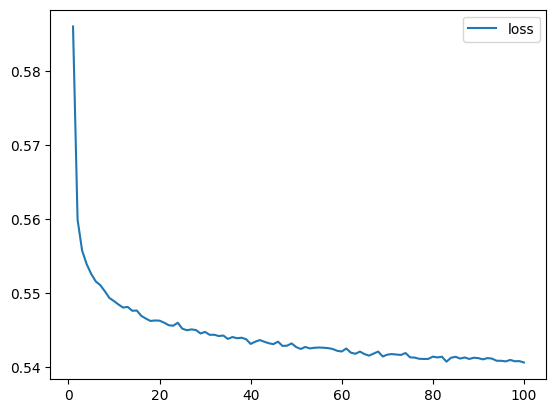

In [19]:
# Displaying a plot of the model loss data

# First, create a DataFrame containing training history
history_df = pd.DataFrame(fit_model.history)

# Secondly, ncrease the index by 1 to match the number of epochs
history_df.index += 1

# lastly, Plot the loss
history_df.plot(y="loss")
plt.show()

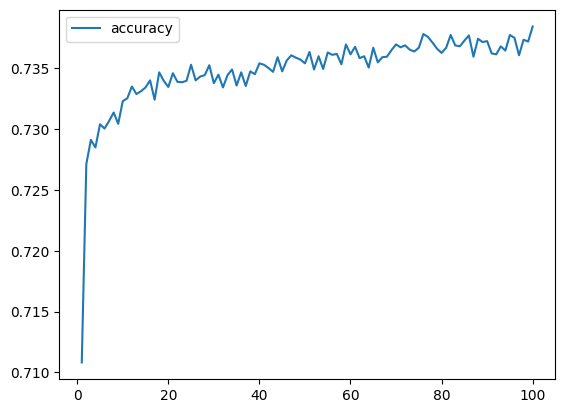

In [20]:
# Displaying a plot of the model accuracy data

# Plotting  the accuracy
history_df.plot(y="accuracy")
plt.show()

In [21]:
# Export our model to HDF5 file
if not os.path.exists('Models'):
    os.makedirs('Models')

dnn.save('Models/AlphabetSoupCharity.h5')
